# Experimento Modelo Fixo

- 10 episódios de Treino
- 10 episódios de Validação
- 20 agentes

### Cada agente é treinado da seguinte forma: 
* No primeiro episódios de treino os agentes aprendem apenas o estimador do estado e ignora o estimador de parametro
* Nos demais episódios treino os agentes aprendem apenas os estimadores de parametros  
* Resultado intermedário é a médias do RMSE dos agentes em cada episódio de teste
* Os a gentes são validados em cada passo dos episódios de validação
* Resultado final é a médias do RMSE dos agentes em cada passo dos episódios de teste

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pmbrl.model import *
from pmbrl.data import *
from pmbrl.experiment import *


In [2]:
n_episodes = 10

data = [generate_episode() for _ in range(n_episodes)]
for i in data:
    print(i.shape)

/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:168: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed a `seed` instead of using `Env.seed` for resetting the environment random number generator.
  logger.deprecation(
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:181: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed `options` to allow the environment initialisation to be passed additional information.
  logger.deprecation(


(59, 8)
(15, 8)
(19, 8)
(22, 8)
(28, 8)
(32, 8)
(100, 8)
(71, 8)
(33, 8)
(20, 8)


# New model test

In [3]:
class TransitionEstimatorNew(nn.Module):
    def __init__(self, s,a,p, hidden_size, output):
        super(TransitionEstimatorNew, self).__init__()
        self.s = s
        self.a = a
        self.p = p
        self.input_param = sum([s,a,s])
        self.input_state = sum([s,a,p])

        self.par1 = nn.Linear(self.input_param, hidden_size)
        self.par2 = nn.Linear(hidden_size, p)
        self.s1 = nn.Linear(self.input_state, hidden_size)
        self.s2 = nn.Linear(hidden_size, output)
        self.relu = nn.ReLU()
        self.than = nn.Tanh()

        self.param_layer = nn.Sequential(self.par1, self.relu, self.par2)
        self.state_layer = nn.Sequential(self.s1, self.than, self.s2)

    def forward(self, x, mode='all'):
        filter_p = lambda p: p[:,:-self.a]
        filter_s = lambda p: p[:,-(self.s + self.a):]
        forward_param = lambda p: self.param_layer(filter_p(p)) 
        forward_state = lambda s, p: self.state_layer(torch.cat([filter_s(s), p], axis=1)) 

        apply = {
            'all': lambda p: forward_state(p, forward_param(p)),
            'param': lambda p: forward_state(p, forward_param(p)),
            'state': lambda p: forward_state(p, torch.ones((p.shape[0], self.p)))
        }
        out = apply[mode](x)
        return out
    

In [4]:


class ModelNew():
    def __init__(self,
                input_size = (2, 1, 2), # 2d for s and s_, 1d for a and a_, and 2d for p,
                hidden_size = 10,
                output = 2, #2d for s_
                learning_rate = [0.001, 0.001],
                criterion_clss = [nn.MSELoss, nn.BCELoss],
                optimizer_clss = [optim.Adam, optim.Adam]
            ) -> None:
        
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output = output
        self.learning_rate = learning_rate

        self.estimatorT = TransitionEstimatorNew(*input_size, hidden_size, output)
        self.estimatorR = RewardEstimatorBase(input_size[0],input_size[1], hidden_size)
        
        self.criterionT = criterion_clss[0]()
        self.criterionR = criterion_clss[1]()
        self.optimizerT = {
            'all' : optimizer_clss[0](self.estimatorT.parameters(), lr=learning_rate[0]),
            'state' : optimizer_clss[0](self.estimatorT.state_layer.parameters(), lr=learning_rate[0]),
            'param' : optimizer_clss[0](self.estimatorT.param_layer.parameters(), lr=learning_rate[0])
        }
        self.optimizerR = optimizer_clss[1](self.estimatorR.parameters(), lr=learning_rate[1])

        self.normalizer = Normalizer(*input_size, output=output)

    def train(self, X_train, y_train, num_epochs=100, debug=False, mode='all'):
        self.normalizer.updateNormalizationParams(X_train, y_train[:,:-1], 'all')
        self.normalizer.setNormalizationParams('all')
        for param in self.estimatorT.parameters():
                param.requires_grad = True 
        if mode == 'state':
            for param in self.estimatorT.param_layer.parameters():
                param.requires_grad = False 
        elif mode == 'param':
            for param in self.estimatorT.state_layer.parameters():
                param.requires_grad = False 

        # Training loop
        for epoch in range(num_epochs):
            # Training Transition Estimator
            self.optimizerT[mode].zero_grad()
            outputs = self.estimatorT(self.normalizer.normilize(X_train, self.normalizer.normalizer_input), mode)
            
            loss = self.criterionT(outputs, self.normalizer.normilize(y_train[:,:-1], self.normalizer.normalizer_output))
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.estimatorT.parameters(), max_norm=1.0) 
            self.optimizerT[mode].step()  

            if debug and (epoch+1) % 10 == 0:
                print(f'Epoch [{epoch+1}/{num_epochs}], Transition Loss: {loss.item():.4f}')  

            # Training Reward Estimator
            self.optimizerR.zero_grad()
            outputs = self.estimatorR(self.normalizer.normilize(X_train, self.normalizer.normalizer_input)[:,3:-1])
            loss = self.criterionR(outputs.squeeze(), y_train[:,-1])

            loss.backward()
            self.optimizerR.step()  

            if debug and (epoch+1) % 10 == 0:
                print(f'Epoch [{epoch+1}/{num_epochs}], Reward Loss: {loss.item():.4f}')  

    def sample(self, x, mode='all'):
        self.normalizer.setNormalizationParams(mode)
        s,r = None, None
        with torch.no_grad():
            s = self.estimatorT(self.normalizer.normilize(x, self.normalizer.normalizer_input), mode)
            r = self.estimatorR(x[:,:self.input_size[0]])
        return self.normalizer.denormilize(s, self.normalizer.normalizer_output), r

In [5]:
n_agents = 20

pmbrl = [ModelNew(learning_rate=[0.0001,0.001]) for _ in range(n_agents)]
mbrl = [ModelBase(learning_rate=[0.0001,0.001]) for _ in range(n_agents)]

In [6]:
training = { # Traning:
    # "mode": "all", # Mode of the PMBRL (All: learn parameters and Transitions)
    "debug": False, # Number of epochs on training
    "num_epochs": 1000, # Number of epochs on training
}

def run(data, models, verbose=False):
    results = []
    for i, epi in enumerate(data):
        if verbose:
            print(f'Episode {i}...')
        X, y = build_train_data(epi)
        for j, agent in enumerate(models):
            if verbose:
                print(f'Agent {j}...')
            if i == 0:
                training['mode'] = 'state'
                train_X = X
            else: 
                training['mode'] = 'param'
                train_X = X

            agent.train(train_X[:-1], y[:-1], **training)
            s,r = agent.sample(X[-1:], mode='all')
            results.append(
                torch.concat([
                    torch.tensor([i, j]),
                    torch.mean((s - y[-1:,:-1])**2, axis=0)**.5,
                    torch.mean((r - y[-1:,-1])**2, axis=0)**.5
                ], axis=0)
            )
    return pd.DataFrame(np.array(results), columns=['epi', 'agent', 's_0', 's_1', 'r']) 

# pmbrl_results = run(data, pmbrl)
# mbrl_results = run(data, mbrl)

In [7]:
print('Training pmbrl...')
pmbrl_results = run(data, pmbrl, verbose=True)
print('pmbrl done!')

pmbrl_plot = pmbrl_results.groupby(by='epi').mean()[['s_0','s_1','r']]

Training pmbrl...
Episode 0...
Agent 0...
Agent 1...
Agent 2...
Agent 3...
Agent 4...
Agent 5...
Agent 6...
Agent 7...
Agent 8...
Agent 9...
Agent 10...
Agent 11...
Agent 12...
Agent 13...
Agent 14...
Agent 15...
Agent 16...
Agent 17...
Agent 18...
Agent 19...
Episode 1...
Agent 0...
Agent 1...
Agent 2...
Agent 3...
Agent 4...
Agent 5...
Agent 6...
Agent 7...
Agent 8...
Agent 9...
Agent 10...
Agent 11...
Agent 12...
Agent 13...
Agent 14...
Agent 15...
Agent 16...
Agent 17...
Agent 18...
Agent 19...
Episode 2...
Agent 0...
Agent 1...
Agent 2...
Agent 3...
Agent 4...
Agent 5...
Agent 6...
Agent 7...
Agent 8...
Agent 9...
Agent 10...
Agent 11...
Agent 12...
Agent 13...
Agent 14...
Agent 15...
Agent 16...
Agent 17...
Agent 18...
Agent 19...
Episode 3...
Agent 0...
Agent 1...
Agent 2...
Agent 3...
Agent 4...
Agent 5...
Agent 6...
Agent 7...
Agent 8...
Agent 9...
Agent 10...
Agent 11...
Agent 12...
Agent 13...
Agent 14...
Agent 15...
Agent 16...
Agent 17...
Agent 18...
Agent 19...
Episode 4.

In [8]:
print('Training mbrl...')
mbrl_results = run(data, mbrl, verbose=True)
print('mbrl done!')

mbrl_plot = mbrl_results.groupby(by='epi').mean()[['s_0','s_1','r']]

Training mbrl...
Episode 0...
Agent 0...
Agent 1...
Agent 2...
Agent 3...
Agent 4...
Agent 5...
Agent 6...
Agent 7...
Agent 8...
Agent 9...
Agent 10...
Agent 11...
Agent 12...
Agent 13...
Agent 14...
Agent 15...
Agent 16...
Agent 17...
Agent 18...
Agent 19...
Episode 1...
Agent 0...
Agent 1...
Agent 2...
Agent 3...
Agent 4...
Agent 5...
Agent 6...
Agent 7...
Agent 8...
Agent 9...
Agent 10...
Agent 11...
Agent 12...
Agent 13...
Agent 14...
Agent 15...
Agent 16...
Agent 17...
Agent 18...
Agent 19...
Episode 2...
Agent 0...
Agent 1...
Agent 2...
Agent 3...
Agent 4...
Agent 5...
Agent 6...
Agent 7...
Agent 8...
Agent 9...
Agent 10...
Agent 11...
Agent 12...
Agent 13...
Agent 14...
Agent 15...
Agent 16...
Agent 17...
Agent 18...
Agent 19...
Episode 3...
Agent 0...
Agent 1...
Agent 2...
Agent 3...
Agent 4...
Agent 5...
Agent 6...
Agent 7...
Agent 8...
Agent 9...
Agent 10...
Agent 11...
Agent 12...
Agent 13...
Agent 14...
Agent 15...
Agent 16...
Agent 17...
Agent 18...
Agent 19...
Episode 4..

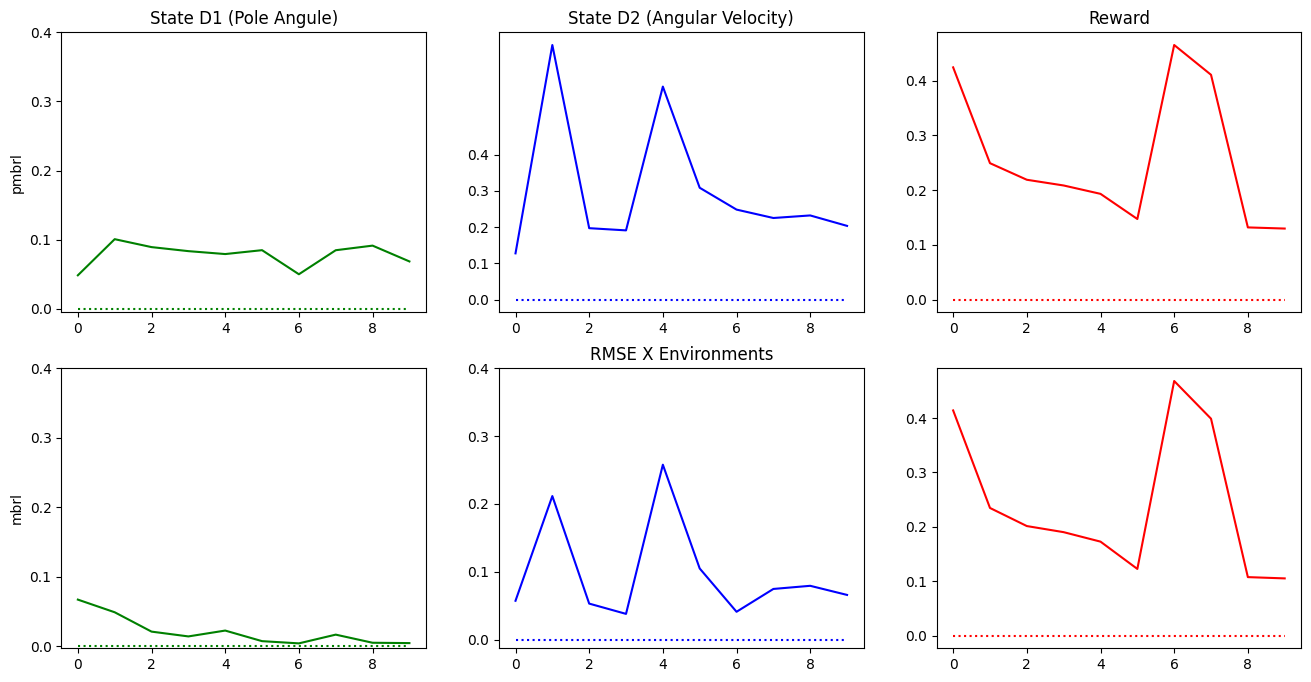

In [9]:
def add_plot(name, data, axis):
    reff = np.zeros(data.shape[0])
    axis[0].set_ylabel(name)
    axis[0].set_ylabel(name)

    axis[0].plot(data['s_0'], color = 'g')
    axis[0].plot(reff, linestyle = 'dotted', color = 'g')
    axis[0].set_yticks(np.arange(5)/10)

    axis[1].plot(data['s_1'], color = 'b')
    axis[1].plot(reff, linestyle = 'dotted', color = 'b')
    axis[1].set_yticks(np.arange(5)/10)

    axis[2].plot(data['r'], color = 'r')
    axis[2].plot(reff, linestyle = 'dotted', color = 'r')
    axis[2].set_yticks(np.arange(5)/10)

fig, axs = plt.subplots(2, 3, figsize=(16, 8))

axs[0][0].set_title('State D1 (Pole Angule)')
axs[0][1].set_title('State D2 (Angular Velocity)')
axs[0][2].set_title('Reward')
axs[1][1].set_title('RMSE X Environments')

add_plot('pmbrl', pmbrl_plot, axs[0])
add_plot('mbrl', mbrl_plot, axs[1])

plt.show()

# Teste

In [10]:
n_episodes = 10

data = [generate_episode() for _ in range(n_episodes)]
for i in data:
    print(i.shape)

/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:168: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed a `seed` instead of using `Env.seed` for resetting the environment random number generator.
  logger.deprecation(
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:181: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed `options` to allow the environment initialisation to be passed additional information.
  logger.deprecation(


(22, 8)
(30, 8)
(11, 8)
(100, 8)
(27, 8)
(18, 8)
(88, 8)
(11, 8)
(23, 8)
(56, 8)


In [11]:
X, y = build_train_data(data[0])
# X[0:1]
# for k, (feature, target) in enumerate(zip(X,y)):
#     print(torch.unsqueeze(feature, axis=0))

pmbrl[0].sample(torch.unsqueeze(X[0], axis=0), mode='all')

(tensor([[0.0111, 0.3353]]), tensor([[0.5000]]))

In [12]:
def run(data, models, verbose=False):
    results = []
    for i, epi in enumerate(data):
        if verbose:
            print(f'Episode {i}...')
        X, y = build_train_data(epi)
        for j, agent in enumerate(models):
            if verbose:
                print(f'Agent {j}...')
            for k, (feature, target) in enumerate(zip(X,y)):
                s,r = agent.sample(torch.unsqueeze(feature, axis=0), mode='all')
                results.append(
                    torch.concat([
                        torch.tensor([i, j, k]),
                        torch.mean((s - target[:-1])**2, axis=0)**.5,
                        torch.mean((r - target[-1])**2, axis=0)**.5
                    ], axis=0)
                )
    return pd.DataFrame(np.array(results), columns=['epi', 'agent', 'step', 's_0', 's_1', 'r']) 


In [13]:
print('Training pmbrl...')
pmbrl_results = run(data, pmbrl, verbose=True)
print('pmbrl done!')

pmbrl_plot = pmbrl_results.groupby(by='step').mean()[['s_0','s_1','r']]

Training pmbrl...
Episode 0...
Agent 0...
Agent 1...
Agent 2...
Agent 3...
Agent 4...
Agent 5...
Agent 6...
Agent 7...
Agent 8...
Agent 9...
Agent 10...
Agent 11...
Agent 12...
Agent 13...
Agent 14...
Agent 15...
Agent 16...
Agent 17...
Agent 18...
Agent 19...
Episode 1...
Agent 0...
Agent 1...
Agent 2...
Agent 3...
Agent 4...
Agent 5...
Agent 6...
Agent 7...
Agent 8...
Agent 9...
Agent 10...
Agent 11...
Agent 12...
Agent 13...
Agent 14...
Agent 15...
Agent 16...
Agent 17...
Agent 18...
Agent 19...
Episode 2...
Agent 0...
Agent 1...
Agent 2...
Agent 3...
Agent 4...
Agent 5...
Agent 6...
Agent 7...
Agent 8...
Agent 9...
Agent 10...
Agent 11...
Agent 12...
Agent 13...
Agent 14...
Agent 15...
Agent 16...
Agent 17...
Agent 18...
Agent 19...
Episode 3...
Agent 0...
Agent 1...
Agent 2...
Agent 3...
Agent 4...
Agent 5...
Agent 6...
Agent 7...
Agent 8...
Agent 9...
Agent 10...
Agent 11...
Agent 12...
Agent 13...
Agent 14...
Agent 15...
Agent 16...
Agent 17...
Agent 18...
Agent 19...
Episode 4.

In [14]:
print('Training mbrl...')
mbrl_results = run(data, mbrl, verbose=True)
print('mbrl done!')

mbrl_plot = mbrl_results.groupby(by='step').mean()[['s_0','s_1','r']]

Training mbrl...
Episode 0...
Agent 0...
Agent 1...
Agent 2...
Agent 3...
Agent 4...
Agent 5...
Agent 6...
Agent 7...
Agent 8...
Agent 9...
Agent 10...
Agent 11...
Agent 12...
Agent 13...
Agent 14...
Agent 15...
Agent 16...
Agent 17...
Agent 18...
Agent 19...
Episode 1...
Agent 0...
Agent 1...
Agent 2...
Agent 3...
Agent 4...
Agent 5...
Agent 6...
Agent 7...
Agent 8...
Agent 9...
Agent 10...
Agent 11...
Agent 12...
Agent 13...
Agent 14...
Agent 15...
Agent 16...
Agent 17...
Agent 18...
Agent 19...
Episode 2...
Agent 0...
Agent 1...
Agent 2...
Agent 3...
Agent 4...
Agent 5...
Agent 6...
Agent 7...
Agent 8...
Agent 9...
Agent 10...
Agent 11...
Agent 12...
Agent 13...
Agent 14...
Agent 15...
Agent 16...
Agent 17...
Agent 18...
Agent 19...
Episode 3...
Agent 0...
Agent 1...
Agent 2...
Agent 3...
Agent 4...
Agent 5...
Agent 6...
Agent 7...
Agent 8...
Agent 9...
Agent 10...
Agent 11...
Agent 12...
Agent 13...
Agent 14...
Agent 15...
Agent 16...
Agent 17...
Agent 18...
Agent 19...
Episode 4..

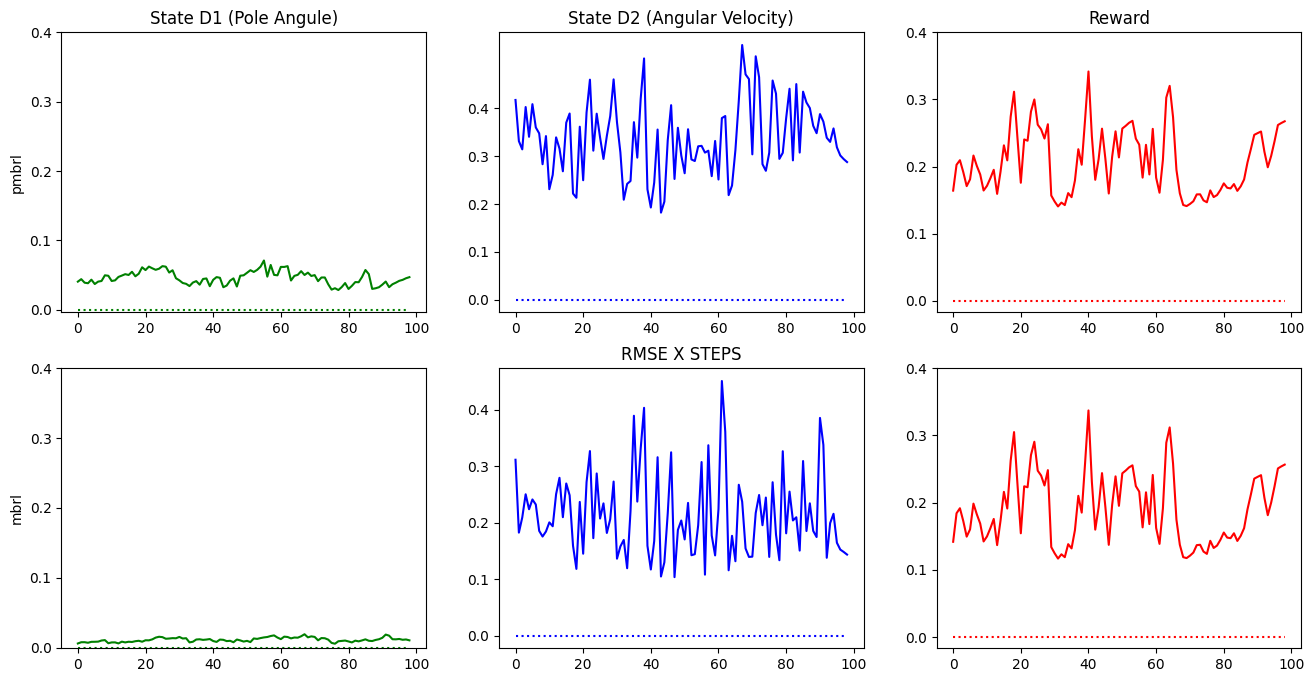

In [15]:
fig, axs = plt.subplots(2, 3, figsize=(16, 8))

axs[0][0].set_title('State D1 (Pole Angule)')
axs[0][1].set_title('State D2 (Angular Velocity)')
axs[0][2].set_title('Reward')
axs[1][1].set_title('RMSE X STEPS')

add_plot('pmbrl', pmbrl_plot, axs[0])
add_plot('mbrl', mbrl_plot, axs[1])

plt.show()